# Maternal & Child Health: Africa vs USA — Exploratory Data Analysis

**Domain:** Health · **Focus:** Maternal & Child Health · **Geography:** 15 African countries + United States · **Period:** 2013–2024

This notebook explores seven World Bank indicators downloaded by `src/ingestion/ingest.py` into `data/raw/`:

| Indicator | Code | Unit |
|---|---|---|
| Maternal mortality ratio | `SH.STA.MMRT` | deaths per 100,000 live births |
| Under-5 mortality rate | `SH.DYN.MORT` | deaths per 1,000 live births |
| Neonatal mortality rate | `SH.DYN.NMRT` | deaths per 1,000 live births |
| Births attended by skilled staff | `SH.STA.BRTC.ZS` | % of births |
| Current health expenditure per capita | `SH.XPD.CHEX.PC.CD` | current US$ |
| DPT immunization | `SH.IMM.IDPT` | % of children 12–23 months |
| Total fertility rate | `SP.DYN.TFRT.IN` | births per woman |

**Questions**
1. How large is the Africa–USA gap in maternal and child mortality, and is it closing?
2. Which African countries are improving fastest, and which are stagnating?
3. How are fertility, skilled birth attendance, immunization and spending related to outcomes?
4. What happened during the COVID-19 period (2020–2021)?

Source: World Bank Open Data API — https://api.worldbank.org/v2/

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pio.renderers.default = "notebook_connected"  # load plotly.js from CDN to keep the notebook small

# Resolve data/raw whether the notebook is run from the project root or notebooks/
RAW_DIR = next(p for p in [Path("data/raw"), Path("../data/raw")] if p.exists())
INDICATORS = {
    "maternal_mortality_ratio": "Maternal mortality (per 100k births)",
    "under5_mortality_rate": "Under-5 mortality (per 1k births)",
    "neonatal_mortality_rate": "Neonatal mortality (per 1k births)",
    "skilled_birth_attendance_pct": "Skilled birth attendance (%)",
    "health_expenditure_per_capita_usd": "Health spend per capita (US$)",
    "immunization_dpt_pct": "DPT immunization (%)",
    "fertility_rate": "Fertility rate (births/woman)",
}
print("Reading raw data from:", RAW_DIR.resolve())

Reading raw data from: /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/2026-09-30_health_africa_usa_maternal_child_health/data/raw


## 1. Load and inspect the raw data

Each raw CSV is in tidy/long format: `country, country_code, year, value, indicator`.
We concatenate them, standardise country names (the API returns e.g. *"Egypt, Arab Rep."*), and tag each country with a region.

In [2]:
frames = [pd.read_csv(RAW_DIR / f"{name}.csv") for name in INDICATORS]
long_df = pd.concat(frames, ignore_index=True)
long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("Int64")
long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
long_df = (long_df.dropna(subset=["year", "value"])
                  .drop_duplicates(subset=["country_code", "year", "indicator"], keep="last"))

NAME_FIX = {"Egypt, Arab Rep.": "Egypt"}
long_df["country"] = long_df["country"].replace(NAME_FIX)
long_df["region"] = np.where(long_df["country_code"] == "USA", "USA", "Africa")

print(f"{len(long_df):,} observations | {long_df['country_code'].nunique()} countries | "
      f"years {long_df['year'].min()}-{long_df['year'].max()}")
coverage = (long_df.groupby("indicator")
                   .agg(rows=("value", "size"), countries=("country_code", "nunique"),
                        first_year=("year", "min"), last_year=("year", "max"))
                   .loc[list(INDICATORS)])
coverage

1,004 observations | 16 countries | years 2013-2024


,rows,countries,first_year,last_year
indicator,,,,
maternal_mortality_ratio,160,16,2014,2023
under5_mortality_rate,160,16,2015,2024
neonatal_mortality_rate,160,16,2015,2024
skilled_birth_attendance_pct,44,16,2013,2022
health_expenditure_per_capita_usd,160,16,2014,2023
immunization_dpt_pct,160,16,2015,2024
fertility_rate,160,16,2015,2024


**Data-quality note.** Six indicators have complete 10-year panels (160 rows = 16 countries × 10 years).
Skilled birth attendance comes from household surveys (DHS/MICS), so it is **sparse** (44 rows) — country averages for this
indicator mix different survey years and should be interpreted with care.

Next we pivot to a wide country-year table for cross-indicator analysis.

In [3]:
wide = (long_df.pivot_table(index=["country", "country_code", "region", "year"],
                            columns="indicator", values="value")
               .reset_index())
wide.columns.name = None
wide["year"] = wide["year"].astype(int)
print(wide.shape)
wide[list(INDICATORS)].describe().T.round(1)

(180, 11)


,count,mean,std,min,25%,50%,75%,max
maternal_mortality_ratio,160.0,269.2,247.5,17.0,122.0,223.5,317.5,1168.0
under5_mortality_rate,160.0,50.1,25.6,6.5,36.7,47.4,64.0,117.8
neonatal_mortality_rate,160.0,21.5,8.2,3.5,16.9,22.2,26.4,39.3
skilled_birth_attendance_pct,44.0,71.9,22.6,15.5,59.0,73.9,92.2,99.2
health_expenditure_per_capita_usd,160.0,771.9,2623.6,21.6,45.2,69.1,103.3,13473.2
immunization_dpt_pct,160.0,85.2,12.4,42.0,78.8,90.0,94.0,99.0
fertility_rate,160.0,3.8,1.0,1.6,3.3,4.1,4.6,5.5


In [4]:
missing = wide[list(INDICATORS)].isna().mean().mul(100).round(1).sort_values(ascending=False)
missing.rename("% missing (country-years)").to_frame()

,% missing (country-years)
skilled_birth_attendance_pct,75.6
under5_mortality_rate,11.1
maternal_mortality_ratio,11.1
neonatal_mortality_rate,11.1
health_expenditure_per_capita_usd,11.1
immunization_dpt_pct,11.1
fertility_rate,11.1


## 2. Latest snapshot — where does each country stand?

For each indicator we take the most recent available value per country.

In [5]:
latest = (long_df.sort_values("year")
                 .groupby(["country", "region", "indicator"]).tail(1)
                 .pivot_table(index=["country", "region"], columns="indicator", values="value")
                 .reset_index())
latest.columns.name = None
latest = latest.sort_values("maternal_mortality_ratio", ascending=False)
latest[["country", "region"] + list(INDICATORS)].round(1).reset_index(drop=True)

,country,region,maternal_mortality_ratio,under5_mortality_rate,neonatal_mortality_rate,skilled_birth_attendance_pct,health_expenditure_per_capita_usd,immunization_dpt_pct,fertility_rate
0,Nigeria,Africa,993.0,115.6,39.0,50.7,66.8,67.0,4.4
1,Cote d'Ivoire,Africa,359.0,64.5,27.4,84.0,87.7,77.0,4.2
2,Tanzania,Africa,276.0,37.0,19.9,63.5,36.3,83.0,4.5
3,Cameroon,Africa,258.0,64.8,24.8,69.0,79.1,77.0,4.3
4,Senegal,Africa,237.0,36.5,20.9,74.5,73.2,91.0,3.8
5,Ghana,Africa,234.0,35.9,18.1,78.9,70.3,95.0,3.3
6,Rwanda,Africa,229.0,37.7,17.4,94.2,52.7,98.0,3.6
7,Ethiopia,Africa,195.0,44.5,25.2,49.8,34.8,73.0,3.9
8,Uganda,Africa,170.0,48.7,21.3,74.2,45.2,91.0,4.2
9,Kenya,Africa,149.0,38.8,20.7,70.2,85.0,91.0,3.2


### Visualization 1 — Maternal mortality ratio, latest year

The dashed line marks the **SDG 3.1 target (< 70 per 100,000 live births by 2030)**.

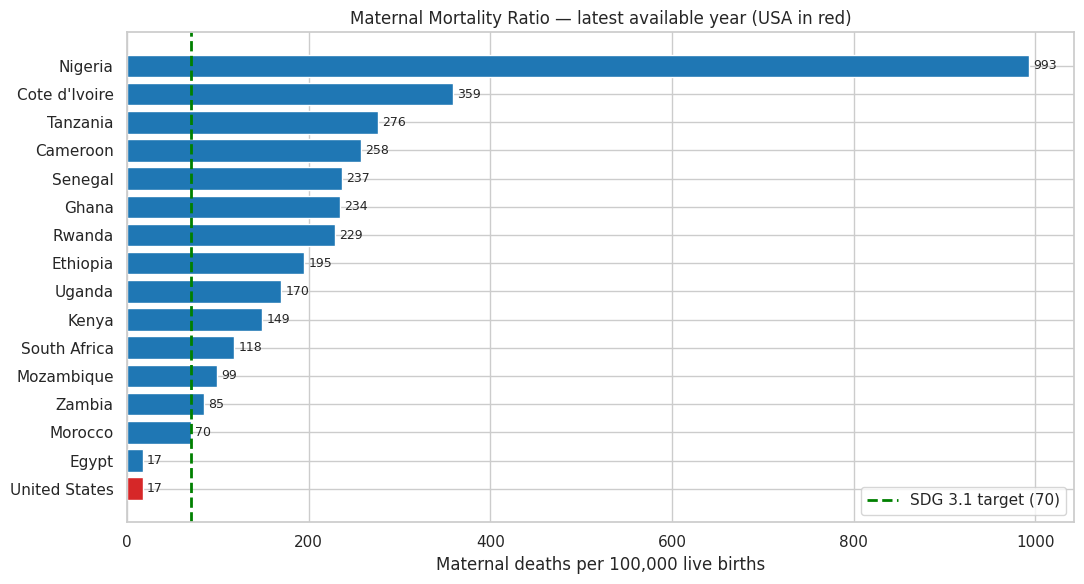

USA MMR: 17 | Africa mean: 233 | Africa median: 195
Nigeria alone: 993 (58x the USA)
African countries meeting SDG 3.1: Egypt


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = latest.sort_values("maternal_mortality_ratio")
colors = ["#d62728" if r == "USA" else "#1f77b4" for r in plot_df["region"]]
bars = ax.barh(plot_df["country"], plot_df["maternal_mortality_ratio"], color=colors)
ax.axvline(70, color="green", ls="--", lw=2, label="SDG 3.1 target (70)")
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
ax.set_xlabel("Maternal deaths per 100,000 live births")
ax.set_title("Maternal Mortality Ratio — latest available year (USA in red)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

usa_mmr = latest.loc[latest.country == "United States", "maternal_mortality_ratio"].iloc[0]
africa_mmr = latest.loc[latest.region == "Africa", "maternal_mortality_ratio"]
print(f"USA MMR: {usa_mmr:.0f} | Africa mean: {africa_mmr.mean():.0f} | Africa median: {africa_mmr.median():.0f}")
print(f"Nigeria alone: {latest.loc[latest.country == 'Nigeria', 'maternal_mortality_ratio'].iloc[0]:.0f} "
      f"({latest.loc[latest.country == 'Nigeria', 'maternal_mortality_ratio'].iloc[0] / usa_mmr:.0f}x the USA)")
print("African countries meeting SDG 3.1:", ", ".join(latest.loc[(latest.region == 'Africa') &
      (latest.maternal_mortality_ratio < 70), "country"]) or "none")

## 3. Trends — is the Africa–USA gap closing?

We compare the **African average** (unweighted mean of the 15 countries) with the USA over time for the three mortality indicators.

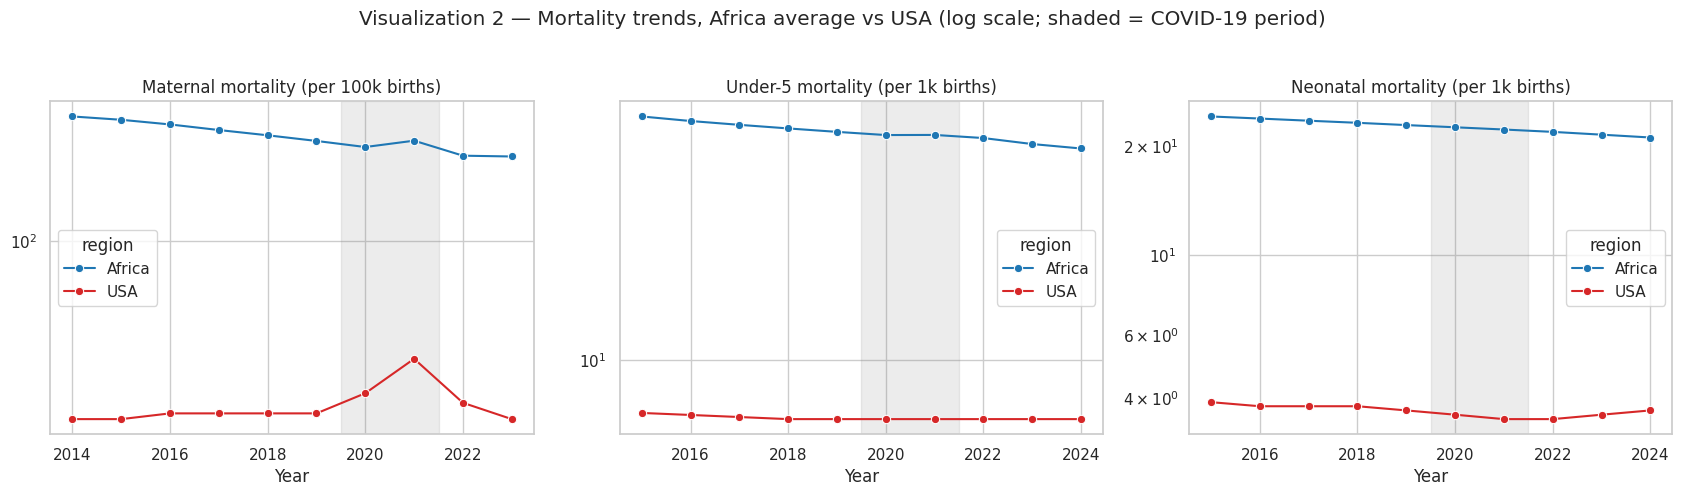

,maternal_mortality_ratio (Africa/USA x),under5_mortality_rate (Africa/USA x),neonatal_mortality_rate (Africa/USA x)
year,,,
2014,20.4,NaN,NaN
2015,19.7,8.7,6.2
2016,17.8,8.6,6.3
2017,16.8,8.5,6.2
2018,16.0,8.4,6.1
2019,15.1,8.2,6.2
2020,11.6,8.0,6.3
2021,8.8,8.0,6.4
2022,11.7,7.8,6.3


In [7]:
mortality = ["maternal_mortality_ratio", "under5_mortality_rate", "neonatal_mortality_rate"]
region_trend = wide.groupby(["region", "year"])[mortality].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, col in zip(axes, mortality):
    sns.lineplot(data=region_trend, x="year", y=col, hue="region", marker="o",
                 palette={"Africa": "#1f77b4", "USA": "#d62728"}, ax=ax)
    ax.set_title(INDICATORS[col])
    ax.set_ylabel("")
    ax.set_xlabel("Year")
    ax.set_yscale("log")
    ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.15)
fig.suptitle("Visualization 2 — Mortality trends, Africa average vs USA (log scale; shaded = COVID-19 period)", y=1.03)
plt.tight_layout()
plt.show()

gap = region_trend.pivot(index="year", columns="region", values=mortality)
ratio = pd.DataFrame({col: gap[col]["Africa"] / gap[col]["USA"] for col in mortality}).round(1)
ratio.columns = [c + " (Africa/USA x)" for c in mortality]
ratio.dropna(how="all")

The ratio table shows that African maternal mortality has fallen steadily, but the **relative** gap to the USA is noisy
because the US MMR itself spiked in 2020–2021 (COVID-19) before recovering. Under-5 mortality shows a slow but consistent
narrowing of the gap, from roughly 8.7× to about 7× the US rate.

### Visualization 3 — Country-level MMR trajectories (interactive)

In [8]:
mmr_long = long_df[long_df["indicator"] == "maternal_mortality_ratio"].sort_values(["country", "year"])
fig = px.line(mmr_long, x="year", y="value", color="country", line_dash="region", markers=True,
              log_y=True, title="Maternal mortality ratio by country, 2014–2023 (log scale)",
              labels={"value": "Maternal deaths per 100,000 live births", "year": "Year"},
              height=550)
fig.add_hline(y=70, line_dash="dot", line_color="green", annotation_text="SDG 3.1 target")
fig.show()

In [9]:
first_last = (mmr_long.groupby("country")
                      .agg(first_year=("year", "min"), last_year=("year", "max"),
                           mmr_first=("value", "first"), mmr_last=("value", "last")))
first_last["pct_change"] = ((first_last.mmr_last - first_last.mmr_first) / first_last.mmr_first * 100).round(1)
first_last["annual_rate_of_reduction_pct"] = (
    (1 - (first_last.mmr_last / first_last.mmr_first) ** (1 / (first_last.last_year - first_last.first_year))) * 100
).round(1)
first_last.sort_values("pct_change")

,first_year,last_year,mmr_first,mmr_last,pct_change,annual_rate_of_reduction_pct
country,,,,,,
Ethiopia,2014,2023,444.0,195.0,-56.1,8.7
Mozambique,2014,2023,210.0,99.0,-52.9,8.0
Zambia,2014,2023,174.0,85.0,-51.1,7.7
Uganda,2014,2023,311.0,170.0,-45.3,6.5
Cameroon,2014,2023,440.0,258.0,-41.4,5.8
Tanzania,2014,2023,454.0,276.0,-39.2,5.4
Senegal,2014,2023,373.0,237.0,-36.5,4.9
Egypt,2014,2023,26.0,17.0,-34.6,4.6
Morocco,2014,2023,106.0,70.0,-34.0,4.5


The SDG 3.1 target implies an **annual rate of reduction (ARR) of ~6.4%** or more for most high-burden countries.
Ethiopia, Mozambique and Zambia exceed that pace, while Nigeria — with the highest burden by far — reduced MMR by only
about 14% over the decade.

## 4. Relationships between indicators

### Visualization 4 — Correlation heatmap (African country-years)

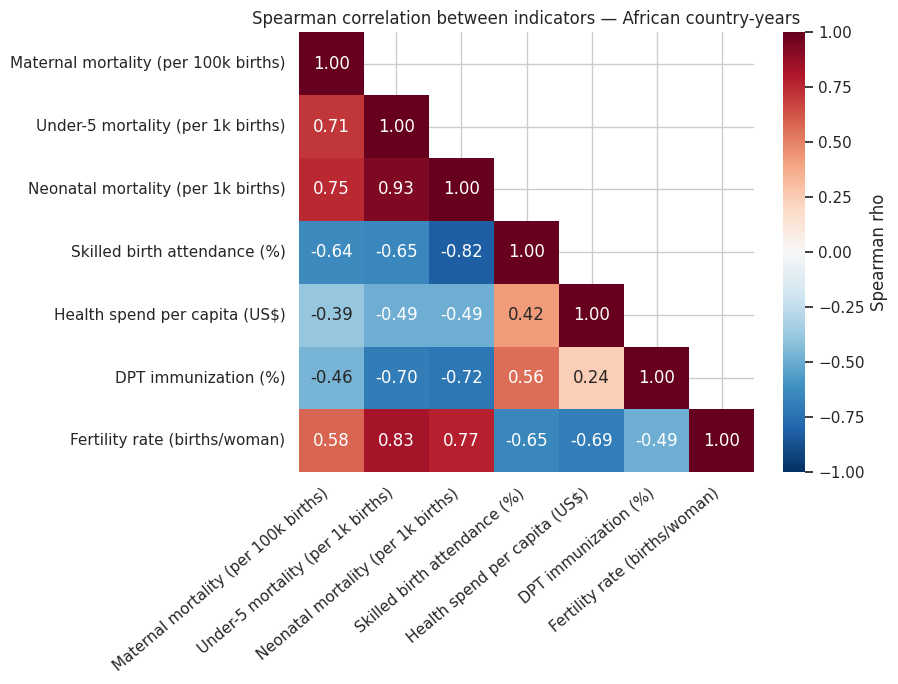

In [10]:
africa = wide[wide["region"] == "Africa"]
corr = africa[list(INDICATORS)].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            xticklabels=[INDICATORS[c] for c in corr.columns],
            yticklabels=[INDICATORS[c] for c in corr.index], ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Spearman correlation between indicators — African country-years")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

Spearman (rank) correlation is used because spending and mortality are heavily skewed. Key patterns:
* **Neonatal and under-5 mortality move together** very strongly — newborn deaths are a large share of child deaths.
* **Higher fertility is associated with higher child mortality**, consistent with the demographic transition.
* **Skilled birth attendance and DPT coverage are negatively associated with mortality**, as is per-capita health spending.

### Visualization 5 — Health spending vs under-5 mortality

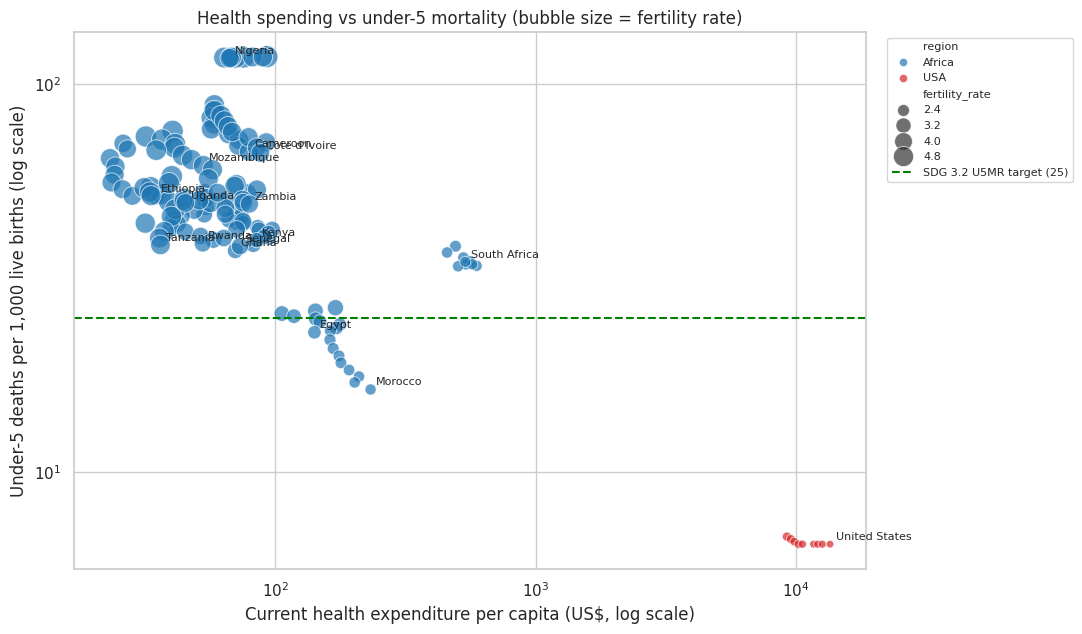

Pearson r on log-log scale (all countries): -0.82


In [11]:
scatter_df = wide.dropna(subset=["health_expenditure_per_capita_usd", "under5_mortality_rate"])
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(data=scatter_df, x="health_expenditure_per_capita_usd", y="under5_mortality_rate",
                hue="region", size="fertility_rate", sizes=(30, 250), alpha=0.7,
                palette={"Africa": "#1f77b4", "USA": "#d62728"}, ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
last_pts = scatter_df.sort_values("year").groupby("country").tail(1)
for _, r in last_pts.iterrows():
    ax.annotate(r["country"], (r["health_expenditure_per_capita_usd"], r["under5_mortality_rate"]),
                fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(25, color="green", ls="--", lw=1.5, label="SDG 3.2 U5MR target (25)")
ax.set_xlabel("Current health expenditure per capita (US$, log scale)")
ax.set_ylabel("Under-5 deaths per 1,000 live births (log scale)")
ax.set_title("Health spending vs under-5 mortality (bubble size = fertility rate)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

log_r = np.corrcoef(np.log(scatter_df.health_expenditure_per_capita_usd), np.log(scatter_df.under5_mortality_rate))[0, 1]
print(f"Pearson r on log-log scale (all countries): {log_r:.2f}")

Spending is strongly associated with outcomes on a log scale, but there is **wide dispersion at similar spending levels**:
Rwanda and Tanzania spend under US$50 per person yet achieve lower child mortality than Nigeria, Cameroon or Côte d'Ivoire,
which spend more. Efficiency of spending (primary care, immunization, skilled attendance) matters as much as volume.

### Visualization 6 — Immunization coverage and child mortality

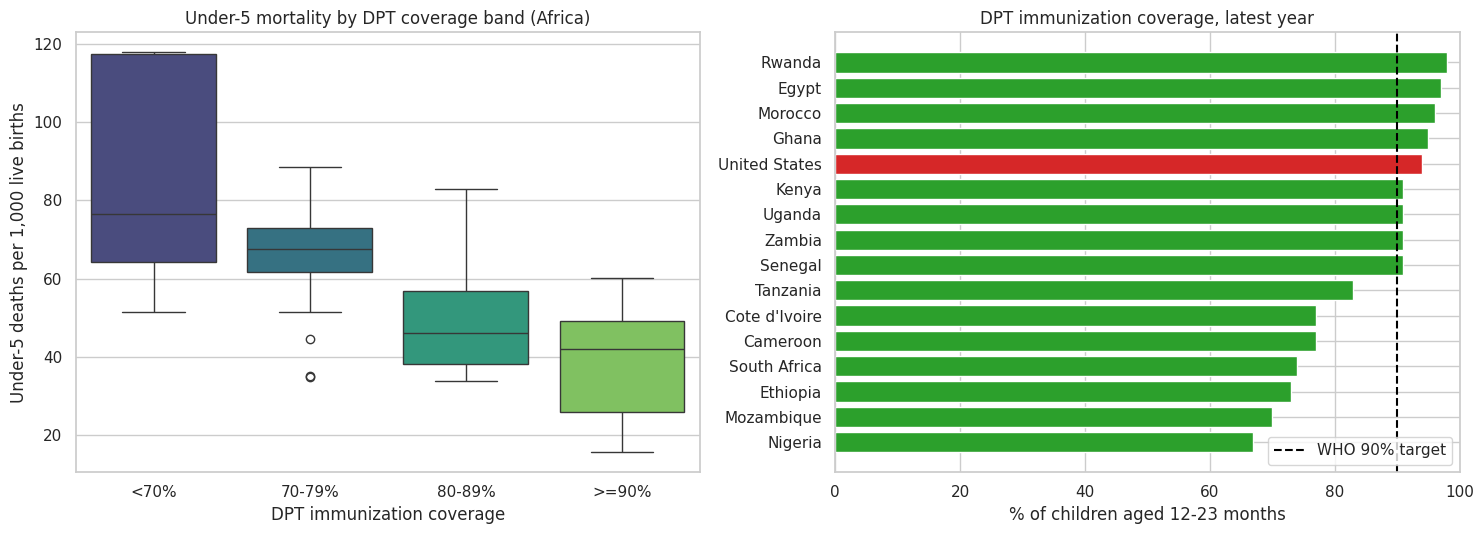

under5_mortality_rate       neonatal_mortality_rate      
                         count  mean                   count  mean
dpt_band                                                          
<70%                        23  87.6                      23  32.9
70-79%                      21  66.1                      21  26.0
80-89%                      34  50.6                      34  21.2
>=90%                       72  39.3                      72  19.2

In [12]:
imm = africa.dropna(subset=["immunization_dpt_pct", "under5_mortality_rate"]).copy()
imm["dpt_band"] = pd.cut(imm["immunization_dpt_pct"], bins=[0, 70, 80, 90, 100],
                         labels=["<70%", "70-79%", "80-89%", ">=90%"], right=False, include_lowest=True)
imm.loc[imm["immunization_dpt_pct"] == 100, "dpt_band"] = ">=90%"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.boxplot(data=imm, x="dpt_band", y="under5_mortality_rate", hue="dpt_band", palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("Under-5 mortality by DPT coverage band (Africa)")
axes[0].set_xlabel("DPT immunization coverage")
axes[0].set_ylabel("Under-5 deaths per 1,000 live births")

dpt_latest = latest.sort_values("immunization_dpt_pct")
axes[1].barh(dpt_latest["country"], dpt_latest["immunization_dpt_pct"],
             color=["#d62728" if r == "USA" else "#2ca02c" for r in dpt_latest["region"]])
axes[1].axvline(90, color="black", ls="--", label="WHO 90% target")
axes[1].set_xlim(0, 100)
axes[1].set_title("DPT immunization coverage, latest year")
axes[1].set_xlabel("% of children aged 12-23 months")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

imm.groupby("dpt_band", observed=True)[["under5_mortality_rate", "neonatal_mortality_rate"]].agg(["count", "mean"]).round(1)

### Visualization 7 — Skilled birth attendance vs maternal mortality

Because skilled-attendance data is survey-based, we pair each survey observation with the MMR estimate from the same year.

In [13]:
sba = wide.dropna(subset=["skilled_birth_attendance_pct", "maternal_mortality_ratio"])
fig = px.scatter(sba, x="skilled_birth_attendance_pct", y="maternal_mortality_ratio", color="region",
                 hover_name="country", hover_data=["year"], log_y=True, trendline=None,
                 color_discrete_map={"Africa": "#1f77b4", "USA": "#d62728"},
                 labels={"skilled_birth_attendance_pct": "Births attended by skilled staff (%)",
                         "maternal_mortality_ratio": "Maternal deaths per 100,000 live births (log)"},
                 title="Skilled birth attendance vs maternal mortality (matched survey years)", height=500)
fig.show()
print(f"Matched observations: {len(sba)} | Spearman rho = "
      f"{sba['skilled_birth_attendance_pct'].corr(sba['maternal_mortality_ratio'], method='spearman'):.2f}")

Matched observations: 40 | Spearman rho = -0.79


## 5. COVID-19 period shock (2020–2021)

### Visualization 8 — Year-over-year change in maternal mortality

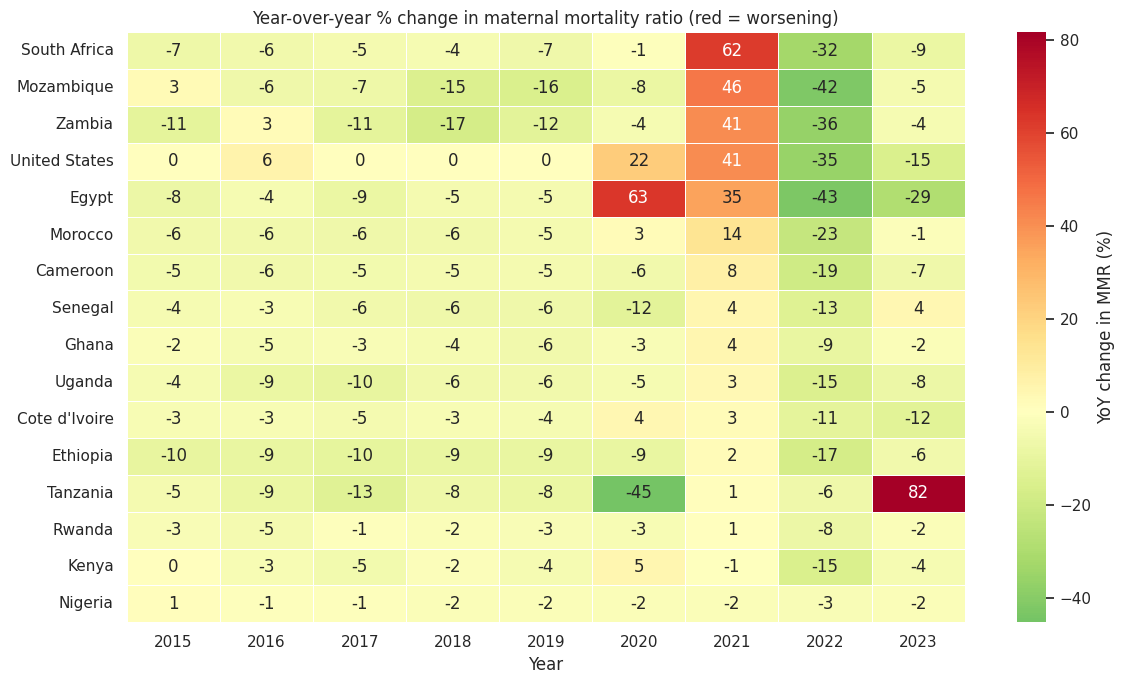

Countries with an MMR increase in 2020 or 2021: 15 of 16
Largest 2021 increases: {'South Africa': 61.9, 'Mozambique': 46.3, 'Zambia': 41.4, 'United States': 40.9, 'Egypt': 35.5}


In [14]:
mmr_w = wide.pivot_table(index="country", columns="year", values="maternal_mortality_ratio")
yoy = mmr_w.pct_change(axis=1, fill_method=None).mul(100).loc[:, 2015:2023]
yoy = yoy.loc[yoy[2021].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(yoy, cmap="RdYlGn_r", center=0, annot=True, fmt=".0f", linewidths=0.4,
            cbar_kws={"label": "YoY change in MMR (%)"}, ax=ax)
ax.set_title("Year-over-year % change in maternal mortality ratio (red = worsening)")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

reversals = (yoy[[2020, 2021]] > 0).any(axis=1)
print(f"Countries with an MMR increase in 2020 or 2021: {reversals.sum()} of {len(yoy)}")
print("Largest 2021 increases:", yoy[2021].nlargest(5).round(1).to_dict())

Maternal mortality **rose in 2020–2021 in most countries**, including the USA (18 → 31 per 100,000 between 2019 and 2021),
South Africa, Egypt, Mozambique and Zambia. Most series recovered in 2022–2023, underscoring how quickly service
disruptions translate into maternal deaths.

## 6. Neonatal share of child deaths

In [15]:
wide["neonatal_share_pct"] = wide["neonatal_mortality_rate"] / wide["under5_mortality_rate"] * 100
share = wide.groupby(["region", "year"])["neonatal_share_pct"].mean().unstack(0).dropna().round(1)
share

region,Africa,USA
year,,
2015,43.1,57.4
2016,44.0,56.7
2017,44.7,57.6
2018,45.3,58.5
2019,45.8,56.9
2020,46.3,55.4
2021,45.8,53.8
2022,46.2,53.8
2023,47.3,55.4


In the USA roughly **54–59% of under-5 deaths occur in the first 28 days** of life; in Africa the share is ~43–48% and
rising as deaths from infections and malnutrition in older children fall faster than newborn deaths. Future African gains
will increasingly depend on **quality of care around birth** — skilled attendance, emergency obstetric care and newborn care.

## 7. Summary of findings

1. **Massive but narrowing gap.** The average African MMR fell from ~347 (2014) to ~233 (2023) per 100,000 live births, yet
   remains more than 13× the US level. Under-5 mortality in Africa is ~7× the US rate.
2. **Nigeria is the outlier.** At ~993 maternal deaths per 100,000 live births, Nigeria's MMR is more than 2.5× the next highest
   country in the sample and fell only ~14% over the decade.
3. **Fast improvers exist.** Ethiopia (−56%), Mozambique (−53%) and Zambia (−51%) more than halved MMR — showing progress at low
   spending levels is possible.
4. **Only Egypt meets SDG 3.1** among the African countries (MMR 17, on par with the USA); Morocco is at the threshold (70).
5. **Determinants.** Fertility, immunization coverage, skilled birth attendance and health spending are all strongly
   correlated with mortality; neonatal and under-5 mortality are almost collinear.
6. **Spending ≠ outcomes.** The USA spends >100× the African average per capita, yet its MMR (17–31) is high for a
   high-income country, and several low-spending African countries outperform higher-spending peers.
7. **COVID-19 reversal.** Most countries — including the USA — saw MMR increases in 2020–2021, followed by partial recovery.

*Caveats:* modeled estimates (MMR, U5MR, NMR) carry uncertainty intervals not shown here; skilled-attendance data is sparse;
the African average is unweighted by population.